Ejercicio 4


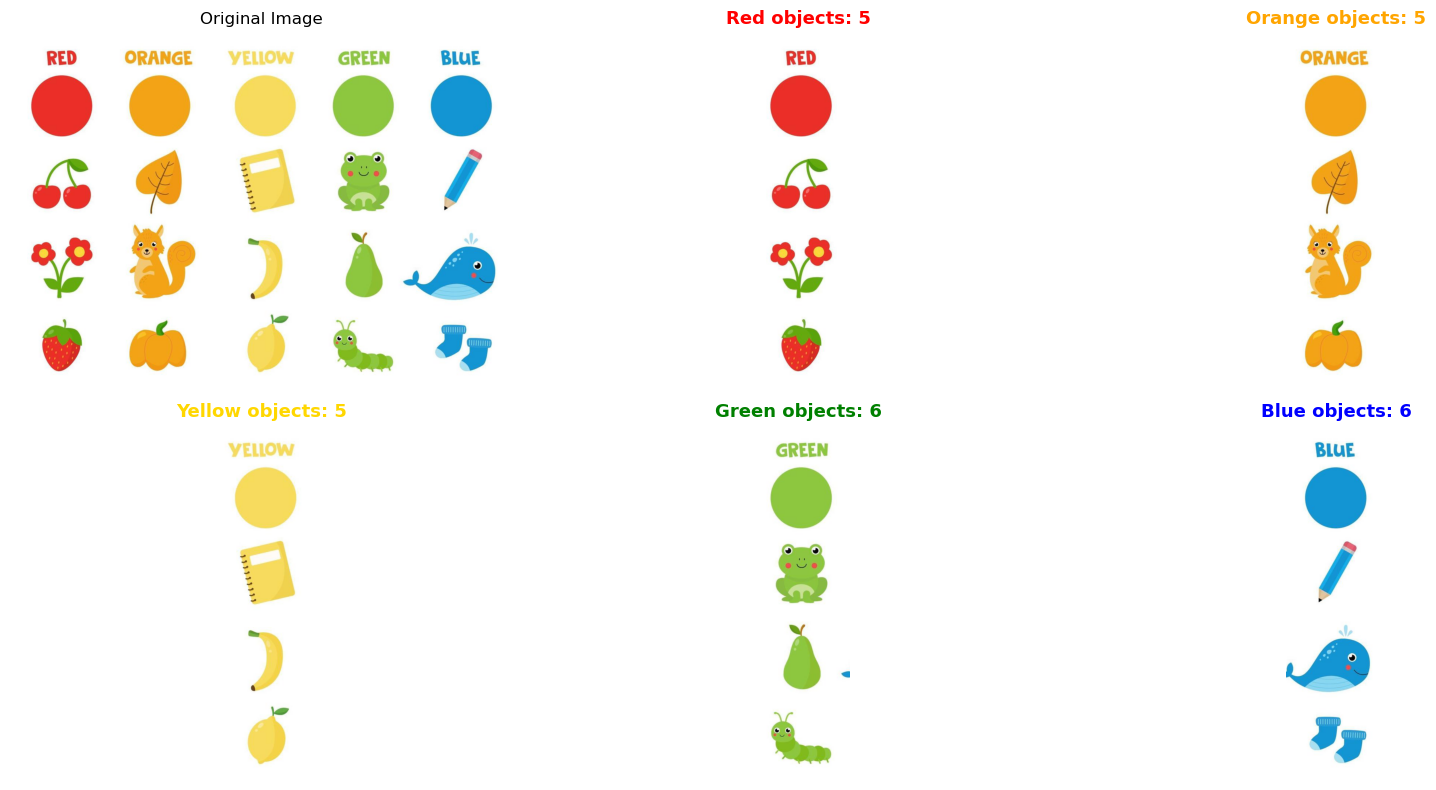

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('colores.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

alto, ancho, _ = img_rgb.shape
num_columnas = 5
ancho_columna = ancho // num_columnas

titulos = ['Red', 'Orange', 'Yellow', 'Green', 'Blue']
imagenes_columnas = []
cantidades = []

for i in range(num_columnas):
    x_inicio = i * ancho_columna
    x_fin = (i + 1) * ancho_columna
    columna = img_rgb[:, x_inicio:x_fin]
    gris = cv2.cvtColor(columna, cv2.COLOR_RGB2GRAY)

    _, thresh = cv2.threshold(gris, 245, 255, cv2.THRESH_BINARY_INV)
    thresh[:60, :] = 0

    kernel = np.ones((2, 2), np.uint8)

    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Dilatación suave para unir partes separadas del mismo objeto
    kernel_dilate = np.ones((4, 4), np.uint8)
    thresh_dilated = cv2.dilate(thresh, kernel_dilate, iterations=2)

    contornos, _ = cv2.findContours(thresh_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    cantidad = 0
    for c in contornos:
        area = cv2.contourArea(c)
        if area > 80:
            cantidad += 1

    imagenes_columnas.append(columna)
    cantidades.append(cantidad)
plt.figure(figsize=(18, 8))
plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

colores_titulo = ['red', 'orange', 'gold', 'green', 'blue']

for i in range(5):
    plt.subplot(2, 3, i + 2)
    plt.imshow(imagenes_columnas[i])
    plt.title(f'{titulos[i]} objects: {cantidades[i]}', color=colores_titulo[i], fontsize=13, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()